# The debt extension — reconciling the register to the official totals

This notebook explains the five `debt_*.csv` files in
[`../deliverables/`](../deliverables): the reconciliation of central-government
debt securities interest and financing to the package's own general-government
aggregates (`GF01_7`, `NLB`), for the United Kingdom, France and Germany.

**Read this before the charts below.** The per-security register described in
`DEBT_KICKOFF.md` — every gilt, OAT and Bund, its coupon, its position through
time — cannot yet be built: the debt-office hosts (DMO, AFT, Finanzagentur)
are unreachable in this run (OQ-8). What this notebook shows instead is the
**aggregate class-level layer** (DD8): the ministries' and statistical
offices' own published totals *by instrument class* (`debt_class_aggregates`),
standing in for the sum a per-security register would otherwise produce. The
two reconciliation chains — interest to `GF01_7`, financing to `NLB` — are
built on top of that aggregate layer exactly as `DEBT_KICKOFF.md` §8
specifies: register sum → step A (finance-ministry cash) → step B (S.1311
national-accounts) → step C (S.13 package total), with every bridge item
either official or declared, and

    official_total = carried_from_previous_step + Σ bridge items + residual

held per (country, year, step). **Every residual here is published, never
allocated** — no line in this notebook is scaled, tilted or adjusted to make
a total match; where the chain does not close, the gap is drawn as its own
bar or its own line.

Everything below is read from `../deliverables/` and nothing is recomputed
from `../data/`.


In [1]:
import io
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image as Image_display, display
from PIL import Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "debt_reference_series.csv").exists())
DELIV = ROOT / "deliverables"
load = lambda n: pd.read_csv(DELIV / f"{n}.csv", float_precision="round_trip")

REF = load("debt_reference_series")
OFFICIAL = load("debt_official_totals")
CLASS_AGG = load("debt_class_aggregates")
INTEREST = load("debt_interest_reconciliation")
FINANCING = load("debt_financing_reconciliation")

REF["date"] = pd.to_datetime(REF["date"])
COUNTRY = {"GBR": "United Kingdom", "FRA": "France", "DEU": "Germany"}

# Fixed categorical palette, assigned by role and reused across every chart in
# this notebook: the same colour always means the same instrument class or
# the same chain step, whichever country or section it appears in.
BLUE, ORANGE, GREEN, PURPLE, RED, TEAL, BROWN, GOLD = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8456ce",
    "#d64550", "#2ba8a0", "#a8763e", "#d1a62b",
)
INK, MUTED, AXIS = "#0b0b0b", "#898781", "#c3c2b7"
SURFACE, SHADE = "#fcfcfb", "#eceae4"

CLASS_COLOR = {
    "fixed_bullet": BLUE, "floating": PURPLE, "inflation_linked": GREEN,
    "bill": ORANGE, "other": BROWN, "mixed": TEAL,
}
STEP_LABEL = {
    "A_cg_cash": "A · CG cash interest", "B_s1311_d41": "B · S.1311 D.41",
    "C_s13_gf01_7": "C · GF01_7",
    "A_cg_cash_requirement": "A · CG net cash requirement",
    "B_s1311_b9": "B · S.1311 B.9", "C_s13_nlb": "C · NLB",
}
STEP_COLOR = {"A": BLUE, "B": ORANGE, "C": GREEN}


def step_color(step):
    return STEP_COLOR[step[0]]


plt.rcParams.update({
    "figure.figsize": (7, 3), "figure.dpi": 72,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "grid.color": AXIS, "grid.alpha": 0.45, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 1.8,
})


def _palette():
    '''A fixed palette of exactly the colours these charts use.

    Quantising a PNG at full colour depth is what keeps this notebook under
    1 MB and renderable everywhere; an *adaptive* palette would instead
    allocate slots by pixel count and crush thin lines to a nearby background
    tint. Fixing the palette -- each mark colour plus its blends toward the
    two backgrounds -- means every hue survives regardless of how little of
    the canvas it covers.
    '''
    from matplotlib.colors import to_rgb

    entries = [to_rgb(SURFACE), to_rgb(SHADE)]
    marks = (INK, MUTED, AXIS, BLUE, ORANGE, GREEN, PURPLE, RED, TEAL, BROWN, GOLD)
    for mark in marks:
        m = to_rgb(mark)
        for ground in (SURFACE, SHADE):
            g = to_rgb(ground)
            entries += [tuple(m[i] + (g[i] - m[i]) * t for i in range(3))
                        for t in (0.0, 0.2, 0.4, 0.6, 0.8)]
    flat = [round(255 * v) for e in entries for v in e]
    pal = Image.new("P", (1, 1))
    pal.putpalette(flat + [0] * (768 - len(flat)))
    return pal


PALETTE = _palette()


def show(fig):
    '''Display a figure as a PNG quantised onto the fixed palette above.'''
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=plt.rcParams["figure.dpi"], bbox_inches="tight")
    plt.close(fig)
    small = Image.open(buf).convert("RGB").quantize(
        palette=PALETTE, dither=Image.Dither.NONE)
    out = io.BytesIO()
    small.save(out, format="PNG", optimize=True)
    display(Image_display(data=out.getvalue()))


def thousands(ax, axis="y"):
    getattr(ax, f"{axis}axis").set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


## 1. Reference series

`debt_reference_series.csv` holds the price indices and interest rates that
inflation-linked and floating-rate securities pay on (DEBT_KICKOFF.md §4.2):
350 series in total, of which **332 are the Bank of England's nominal, real,
inflation and OIS month-end yield curves** — one series per maturity point.
Those are summarised in one chart (the UK nominal curve at three tenors) and
otherwise left out of the table below, which lists the other 18 series in
full: their span is what matters here, not their shape.


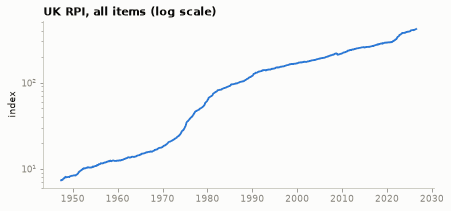

In [2]:
def line(ax, series_id, label=None, color=BLUE, **kw):
    d = REF[REF.series_id == series_id].sort_values("date")
    ax.plot(d.date, d.value, color=color, label=label or series_id, **kw)
    return d


fig, ax = plt.subplots()
line(ax, "UK_RPI", color=BLUE)
ax.set_yscale("log")
ax.set_title("UK RPI, all items (log scale)")
ax.set_ylabel("index")
show(fig)


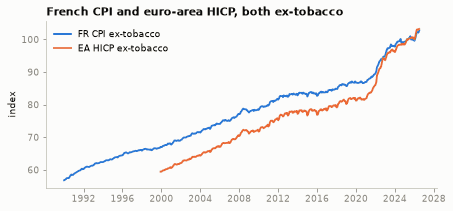

In [3]:
fig, ax = plt.subplots()
line(ax, "FR_CPI_XT", "FR CPI ex-tobacco", BLUE)
line(ax, "EA_HICP_XT", "EA HICP ex-tobacco", ORANGE)
ax.set_title("French CPI and euro-area HICP, both ex-tobacco")
ax.set_ylabel("index")
ax.legend()
show(fig)


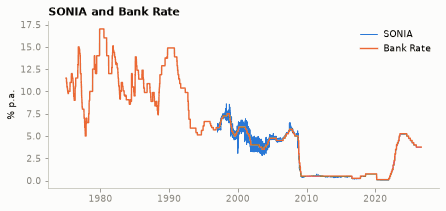

In [4]:
fig, ax = plt.subplots()
line(ax, "UK_SONIA", "SONIA", BLUE, linewidth=0.9)
line(ax, "UK_BANK_RATE", "Bank Rate", ORANGE, linewidth=1.4)
ax.set_title("SONIA and Bank Rate")
ax.set_ylabel("% p.a.")
ax.legend()
show(fig)


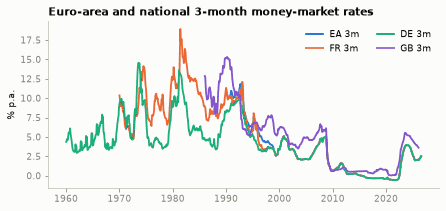

In [5]:
fig, ax = plt.subplots()
line(ax, "EA_MM_3M", "EA 3m", BLUE)
line(ax, "FR_IR3", "FR 3m", ORANGE)
line(ax, "DE_IR3", "DE 3m", GREEN)
line(ax, "GB_IR3", "GB 3m", PURPLE)
ax.set_title("Euro-area and national 3-month money-market rates")
ax.set_ylabel("% p.a.")
ax.legend(ncol=2)
show(fig)


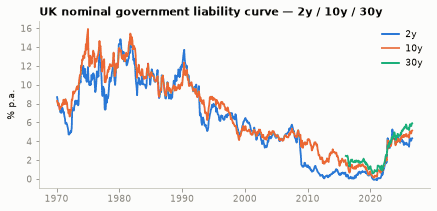

In [6]:
fig, ax = plt.subplots()
line(ax, "UK_GLC_NOMINAL_2Y", "2y", BLUE)
line(ax, "UK_GLC_NOMINAL_10Y", "10y", ORANGE)
line(ax, "UK_GLC_NOMINAL_30Y", "30y", GREEN)
ax.set_title("UK nominal government liability curve — 2y / 10y / 30y")
ax.set_ylabel("% p.a.")
ax.legend()
show(fig)


In [7]:
CURVE_PREFIX = ("UK_GLC_", "UK_OIS_")
non_curve = REF[~REF.series_id.str.startswith(CURVE_PREFIX)]
span = (non_curve.groupby("series_id")
        .agg(first_date=("date", "min"), last_date=("date", "max"),
             n_obs=("date", "size"), unit=("unit", "first"))
        .sort_index())
print(f"{REF.series_id.nunique()} series in total; {span.shape[0]} shown here, "
      f"{REF.series_id.nunique() - span.shape[0]} are BoE curve points (UK_GLC_*/UK_OIS_*).")
span


350 series in total; 18 shown here, 332 are BoE curve points (UK_GLC_*/UK_OIS_*).


,first_date,last_date,n_obs,unit
series_id,,,,
DE_HICP_XT,1996-01-01,2026-07-01,367,index
DE_IR3,1960-01-01,2026-08-01,800,pct_pa
DE_LT10,1956-05-01,2026-08-01,844,pct_pa
DE_MCBY,1980-01-01,2026-07-01,559,pct_pa
EA_HICP_XT,1999-12-01,2026-07-01,320,index
EA_MCBY,1990-01-01,2026-07-01,439,pct_pa
EA_MM_3M,1990-01-01,2026-08-01,440,pct_pa
EA_MM_6M,1994-01-01,2026-08-01,392,pct_pa
FR_CPI_XT,1990-01-01,2026-07-01,439,index


## 2. Official intermediates

`debt_official_totals.csv` holds the six numbers each country-year can carry:
the three interest-chain totals (step A finance-ministry cash interest, step
B S.1311 D.41, step C the package's `GF01_7`) and the three financing-chain
totals (step A the central-government net cash requirement — CGNCR / besoin
de financement / Nettokreditaufnahme — step B S.1311 `B.9`, step C the
package's `NLB`). A cell is null where the source is unreachable (OQ-8, e.g.
the AFT for France) or the year is outside the source's coverage.

**Sign note for financing.** The net cash requirement is published as a
borrowing *need* (positive when the government borrows); `B.9` and `NLB` are
net lending(+)/borrowing(–), the opposite sign. The chart below therefore
plots **NET BORROWING = −B.9** and **−NLB** alongside CGNCR/NKA exactly as
published, so the three lines sit on the same side of zero and can be read
together.


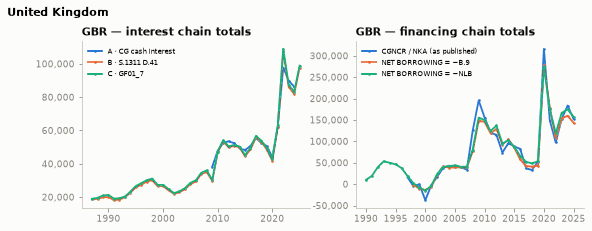

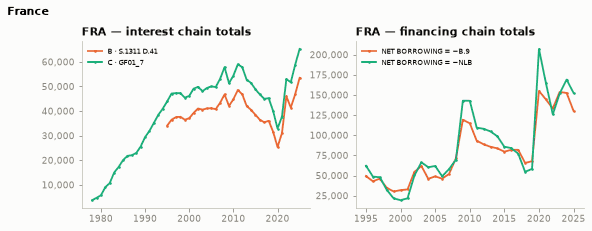

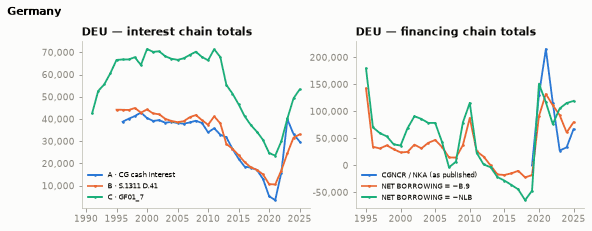

In [8]:
def official_pivot(iso3, chain):
    sub = OFFICIAL[(OFFICIAL.iso3 == iso3) & (OFFICIAL.chain == chain)]
    return sub.pivot_table(index="year", columns="step", values="value_lcu_mn")


for iso in ["GBR", "FRA", "DEU"]:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))

    p = official_pivot(iso, "interest")
    for step in ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"]:
        if step in p.columns:
            axes[0].plot(p.index, p[step], color=step_color(step),
                         marker=".", markersize=3, label=STEP_LABEL[step])
    axes[0].set_title(f"{iso} — interest chain totals")
    thousands(axes[0])
    axes[0].legend(fontsize=7)

    p = official_pivot(iso, "financing")
    if "A_cg_cash_requirement" in p.columns:
        axes[1].plot(p.index, p["A_cg_cash_requirement"], color=STEP_COLOR["A"],
                     marker=".", markersize=3, label="CGNCR / NKA (as published)")
    if "B_s1311_b9" in p.columns:
        axes[1].plot(p.index, -p["B_s1311_b9"], color=STEP_COLOR["B"],
                     marker=".", markersize=3, label="NET BORROWING = −B.9")
    if "C_s13_nlb" in p.columns:
        axes[1].plot(p.index, -p["C_s13_nlb"], color=STEP_COLOR["C"],
                     marker=".", markersize=3, label="NET BORROWING = −NLB")
    axes[1].set_title(f"{iso} — financing chain totals")
    thousands(axes[1])
    axes[1].legend(fontsize=7)

    fig.suptitle(COUNTRY[iso], x=0.01, ha="left", fontsize=10.5, fontweight="bold", y=1.04)
    show(fig)


## 3. Aggregate layer

`debt_class_aggregates.csv` is the DD8 stand-in for the register: the
ministries' and statistical offices' own instrument-class totals. It carries
several *alternative* measures of the same stock side by side (a source's own
grand total next to the components it sums to) — stacking all of them would
double-count, so each chart below uses exactly the rows the reconciliation
chains themselves use (`in_register == True`), and never sums a total row
together with its components:

- **Germany** — every in-register row: the eleven Bundeswertpapiere lines
  (Bunds by maturity band, Bobls, Schätze, Bubills, Bund/Bobl-ei, green
  twins, other and the WSF top-up issuance), no separate "total" row exists
  at this level.
- **United Kingdom** — `gilts_all` (the DMR's own gilts total, `mixed` class
  because the DMR does not split it by class at every date) plus
  `treasury_bills`; a second chart shows the DMR's own conventional /
  index-linked / bills split, available only 2023–2025.
- **France** — `btf`, `oat_btan_fixed` and `oati_oatei` from 2009, the AFT's
  own class split; `dette_négociable_total`, `oat_btan_all` and `taux_fixe`
  are alternative totals and are excluded here.


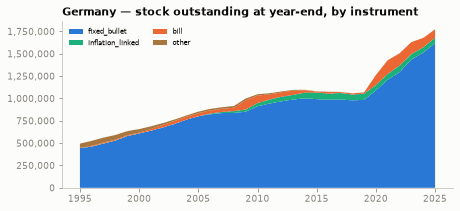

In [9]:
def stock_stack(sub, title, ax=None):
    # Stacks stock_year_end by instrument_class, summing sub-types within a
    # class (Germany's eleven Bundeswertpapiere lines collapse to four).
    p = sub.pivot_table(index="year", columns="instrument_class", values="value_lcu_mn", aggfunc="sum")
    order = sorted(p.columns, key=lambda c: list(CLASS_COLOR).index(c) if c in CLASS_COLOR else 99)
    colors = [CLASS_COLOR.get(c, MUTED) for c in order]
    ax = ax or plt.subplots()[1]
    ax.stackplot(p.index, [p[c].fillna(0) for c in order], labels=order, colors=colors)
    ax.set_title(title)
    thousands(ax)
    ax.legend(fontsize=7, ncol=2)
    return ax


deu_stock = CLASS_AGG[(CLASS_AGG.iso3 == "DEU") & (CLASS_AGG.in_register) &
                       (CLASS_AGG.measure == "stock_year_end")]
fig, ax = plt.subplots()
stock_stack(deu_stock, "Germany — stock outstanding at year-end, by instrument", ax)
show(fig)


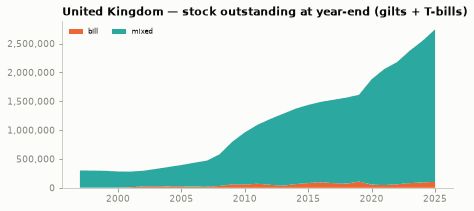

In [10]:
gbr_stock = CLASS_AGG[(CLASS_AGG.iso3 == "GBR") & (CLASS_AGG.measure == "stock_year_end") &
                       (CLASS_AGG.sub_type.isin(["gilts_all", "treasury_bills"]))]
fig, ax = plt.subplots()
stock_stack(gbr_stock, "United Kingdom — stock outstanding at year-end (gilts + T-bills)", ax)
show(fig)


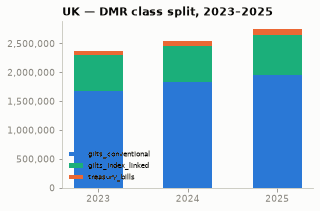

In [11]:
gbr_dmr = CLASS_AGG[(CLASS_AGG.iso3 == "GBR") & (CLASS_AGG.measure == "stock_year_end") &
                     (CLASS_AGG.year >= 2023) &
                     (CLASS_AGG.sub_type.isin(
                         ["gilts_conventional", "gilts_index_linked", "treasury_bills"]))]
p = gbr_dmr.pivot_table(index="year", columns="sub_type", values="value_lcu_mn")
fig, ax = plt.subplots(figsize=(4.5, 3))
x = range(len(p.index))
bottom = pd.Series(0.0, index=p.index)
for col in ["gilts_conventional", "gilts_index_linked", "treasury_bills"]:
    cls = gbr_dmr[gbr_dmr.sub_type == col].instrument_class.iloc[0]
    ax.bar(x, p[col], bottom=bottom, color=CLASS_COLOR[cls], label=col, width=0.55)
    bottom += p[col].fillna(0)
ax.set_xticks(list(x)); ax.set_xticklabels(p.index.astype(str))
ax.set_title("UK — DMR class split, 2023–2025")
thousands(ax)
ax.legend(fontsize=7)
show(fig)


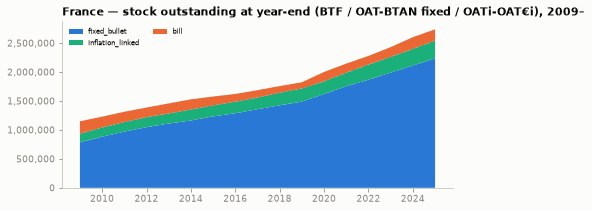

In [12]:
fra_stock = CLASS_AGG[(CLASS_AGG.iso3 == "FRA") & (CLASS_AGG.measure == "stock_year_end") &
                       (CLASS_AGG.sub_type.isin(["btf", "oat_btan_fixed", "oati_oatei"]))]
fig, ax = plt.subplots()
stock_stack(fra_stock, "France — stock outstanding at year-end (BTF / OAT-BTAN fixed / OATi-OAT€i), 2009–", ax)
show(fig)


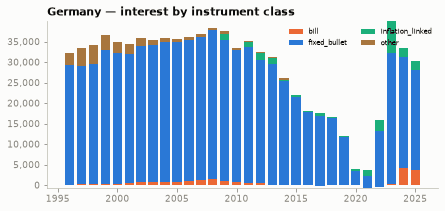

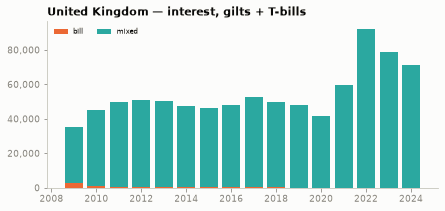

In [13]:
def class_bars(sub, title, ax=None):
    p = sub.pivot_table(index="year", columns="instrument_class", values="value_lcu_mn", aggfunc="sum")
    ax = ax or plt.subplots()[1]
    bottom = pd.Series(0.0, index=p.index)
    for c in p.columns:
        ax.bar(p.index, p[c].fillna(0), bottom=bottom, color=CLASS_COLOR.get(c, MUTED),
               label=c, width=0.8)
        bottom += p[c].fillna(0)
    ax.set_title(title)
    thousands(ax)
    ax.legend(fontsize=7, ncol=2)
    return ax


deu_int = CLASS_AGG[(CLASS_AGG.iso3 == "DEU") & (CLASS_AGG.in_register) & (CLASS_AGG.measure == "interest")]
fig, ax = plt.subplots()
class_bars(deu_int, "Germany — interest by instrument class", ax)
show(fig)

gbr_int = CLASS_AGG[(CLASS_AGG.iso3 == "GBR") & (CLASS_AGG.measure == "interest") &
                     (CLASS_AGG.sub_type.isin(["gilts_all", "treasury_bills"]))]
fig, ax = plt.subplots()
class_bars(gbr_int, "United Kingdom — interest, gilts + T-bills", ax)
show(fig)


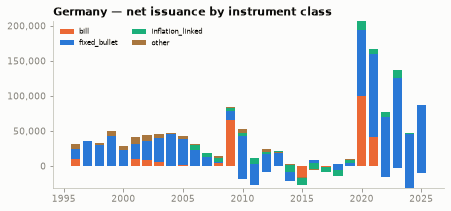

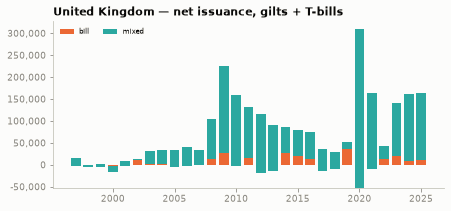

In [14]:
deu_ni = CLASS_AGG[(CLASS_AGG.iso3 == "DEU") & (CLASS_AGG.in_register) & (CLASS_AGG.measure == "net_issuance")]
fig, ax = plt.subplots()
class_bars(deu_ni, "Germany — net issuance by instrument class", ax)
show(fig)

gbr_ni = CLASS_AGG[(CLASS_AGG.iso3 == "GBR") & (CLASS_AGG.measure == "net_issuance") &
                    (CLASS_AGG.sub_type.isin(["gilts_all", "treasury_bills"]))]
fig, ax = plt.subplots()
class_bars(gbr_ni, "United Kingdom — net issuance, gilts + T-bills", ax)
show(fig)


France publishes net issuance at class level for BTF only among these three sub-types (['btf']); OAT-BTAN fixed and OATi/OAT€i carry a stock series but no separate net-issuance line here.


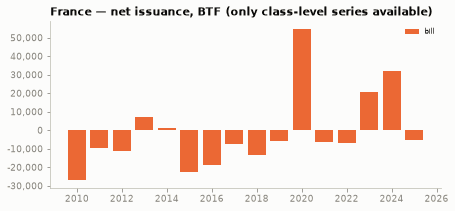

In [15]:
fra_ni = CLASS_AGG[(CLASS_AGG.iso3 == "FRA") & (CLASS_AGG.measure == "net_issuance") &
                    (CLASS_AGG.sub_type.isin(["btf", "oat_btan_fixed", "oati_oatei"]))]
print("France publishes net issuance at class level for BTF only among these three "
      f"sub-types ({fra_ni.sub_type.unique().tolist()}); OAT-BTAN fixed and OATi/OAT€i "
      "carry a stock series but no separate net-issuance line here.")
fig, ax = plt.subplots()
class_bars(fra_ni, "France — net issuance, BTF (only class-level series available)", ax)
show(fig)


## 4. The interest chain

`debt_interest_reconciliation.csv` holds, per (country, year, step), the
carried-forward value, every bridge item, the official total and the
residual — `official_total = carried + Σ bridge items + residual`
(DEBT_KICKOFF.md §8, V32). The waterfalls below take **the latest year each
country's step-C residual is not null** and show all three steps side by
side: the grey bar is the value carried in from the previous step, coloured
bars are bridge items (orange where negative), the red bar is the residual,
and the dark bar on the right is the official total the step reconciles to.
Where a step has no data for that year at all (register or step A can be
blocked independently of C), the panel says so instead of drawing empty
bars. Bridge items beyond the six largest by size are grouped into "other".


In [16]:
def step_items(df, iso3, step, year, max_bridge=6):
    sub = df[(df.iso3 == iso3) & (df.step == step) & (df.year == year)]
    d = dict(zip(sub.item, sub.value_lcu_mn))
    carried = d.get("carried_from_previous_step")
    official = d.get("official_total")
    residual = d.get("residual")
    bridge = [(k, v) for k, v in d.items()
              if k not in ("carried_from_previous_step", "official_total", "residual")
              and pd.notna(v) and v != 0]
    bridge.sort(key=lambda kv: -abs(kv[1]))
    if len(bridge) > max_bridge:
        head, tail = bridge[:max_bridge - 1], bridge[max_bridge - 1:]
        bridge = head + [(f"other ({len(tail)})", sum(v for _, v in tail))]
    return carried, bridge, residual, official


def waterfall(ax, iso3, df, step, year, title):
    carried, bridge, residual, official = step_items(df, iso3, step, year)
    if pd.isna(carried) and pd.isna(official):
        ax.text(0.5, 0.5, "no data\nfor this year", ha="center", va="center",
                transform=ax.transAxes, color=MUTED, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title)
        return
    labels, lefts, widths, colors = [], [], [], []
    cum = 0.0
    if pd.notna(carried):
        labels.append("carried"); lefts.append(0); widths.append(carried); colors.append(MUTED)
        cum = carried
    for lab, val in bridge:
        lefts.append(min(cum, cum + val)); widths.append(abs(val))
        colors.append(BLUE if val >= 0 else ORANGE)
        labels.append(lab.replace("out_of_register_", "").replace("_", " ")[:22])
        cum += val
    if pd.notna(residual):
        lefts.append(min(cum, cum + residual)); widths.append(abs(residual))
        colors.append(RED); labels.append("residual")
        cum += residual
    y = range(len(labels))
    ax.barh(list(y), widths, left=lefts, color=colors, height=0.65)
    if pd.notna(official):
        labels.append("official total")
        y = range(len(labels))
        ax.barh([len(labels) - 1], [official], left=[0], color=INK, height=0.65)
    ax.set_yticks(list(y)); ax.set_yticklabels(labels, fontsize=6.5)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=9.5)
    thousands(ax, axis="x")
    ax.tick_params(axis="x", labelsize=6.5, rotation=30)


def waterfall_page(df, iso3, steps, chain_name):
    c_step = steps[-1]
    year = df[(df.iso3 == iso3) & (df.step == c_step) &
              (df.item == "residual")].dropna(subset=["value_lcu_mn"]).year.max()
    fig, axes = plt.subplots(1, len(steps), figsize=(3.4 * len(steps), 3.2))
    for ax, step in zip(axes, steps):
        waterfall(ax, iso3, df, step, year, f"{STEP_LABEL[step]}, {year}")
    fig.suptitle(f"{COUNTRY[iso3]} — {chain_name} chain, {year}", x=0.01, ha="left",
                 fontsize=10.5, fontweight="bold", y=1.05)
    show(fig)
    return year


def residual_over_time(df, iso3, steps, title):
    fig, ax = plt.subplots()
    for step in steps:
        sub = df[(df.iso3 == iso3) & (df.step == step) & (df.item == "residual")]
        s = sub.set_index("year").value_lcu_mn.sort_index()
        full = s.reindex(range(int(s.index.min()), int(s.index.max()) + 1))
        ax.plot(full.index, full.values, color=STEP_COLOR[step[0]],
                marker=".", markersize=3, label=STEP_LABEL[step])
    ax.axhline(0, color=AXIS, linewidth=0.7)
    ax.set_title(title)
    thousands(ax)
    ax.legend(fontsize=7)
    show(fig)


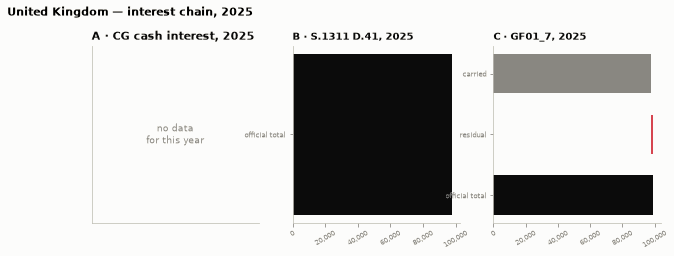

In [17]:
gbr_year = waterfall_page(INTEREST, "GBR", ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"], "interest")


**Reading the UK panels.** Step A (register → CG cash interest) and even the
register sum are null for 2025 — HMT's NLF cash-interest series has not yet
been published for the year, a *publication lag*, not a blocked source
(2024 is complete). Step B carries no bridge items: HMT's cash interest feeds
`S.1311 D.41` directly. Step C's residual (£1.1bn against a £98.9bn total) is
the **COFOG-vs-D.41 wedge plus intra-`S.13` consolidation** (state/local and
social-security interest do not apply to a unitary UK central-government
register the same way, and `GF01_7` is compiled on the COFOG functional
concept rather than the D.41 instrument concept).


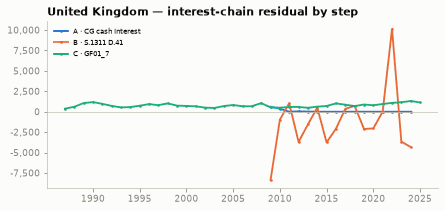

In [18]:
residual_over_time(INTEREST, "GBR", ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"],
                    "United Kingdom — interest-chain residual by step")


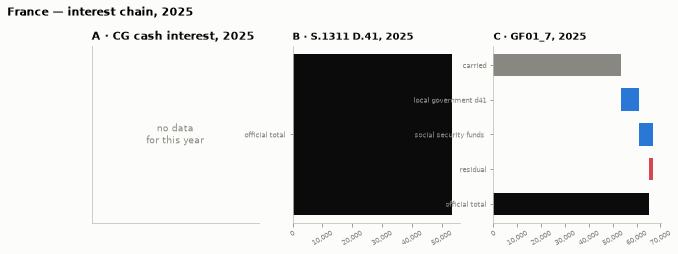

In [19]:
fra_year = waterfall_page(INTEREST, "FRA", ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"], "interest")


**Reading the France panels.** Step A is entirely blocked: `FRA_PLF_P117`
(the PLF programme 117 swaps/loans detail that step A's bridge would use) has
no data in this run (OQ-8), so both the register sum and step A's official
total are null in every year, not just 2025 — there is no "carried" bar to
draw. Step B shows the official total alone: the PLF's central-government
cash interest feeds `D.41` with no declared bridge items. Step C's residual
(−€1.6bn) is **subsector consolidation and the COFOG-vs-D.41 wedge**: local
government and social-security D.41 interest are added as bridge items, and
what is left over after adding them to the CG figure is the gap between the
sum of subsector D.41 and the package's own COFOG-based `GF01_7`.


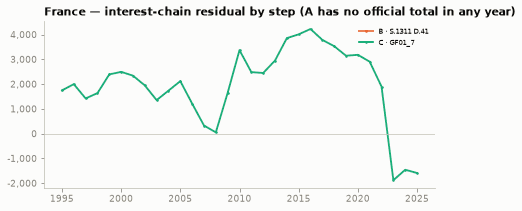

In [20]:
residual_over_time(INTEREST, "FRA", ["B_s1311_d41", "C_s13_gf01_7"],
                    "France — interest-chain residual by step (A has no official total in any year)")


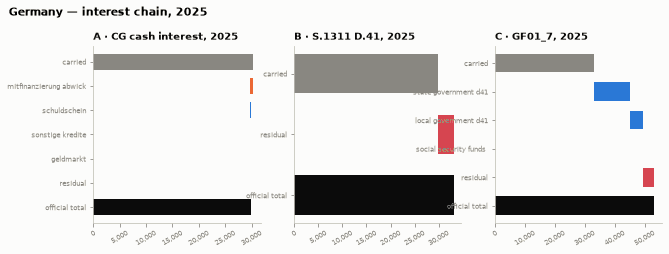

In [21]:
deu_year = waterfall_page(INTEREST, "DEU", ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"], "interest")


**Reading the Germany panels.** Step A is the fullest of the three: the
Kreditaufnahmebericht's Verzinsung annex gives central-government cash
interest directly, with `Geldmarkt`, `Schuldschein`, other-credit and
Abwicklungsanstalten/KfW co-financing interest as declared bridge items
against the register sum — the step-A residual is essentially zero (leaves
vs ministry total agree to within rounding). Step B's residual (+€3.2bn) is
**cash-to-accrual timing and premium/discount amortisation**: cash interest
paid in the year versus D.41 interest accrued to it. Step C's residual
(+€3.7bn) is **subsector consolidation and the COFOG-vs-D.41 wedge**, after
adding state, local and social-security D.41 interest as bridge items.


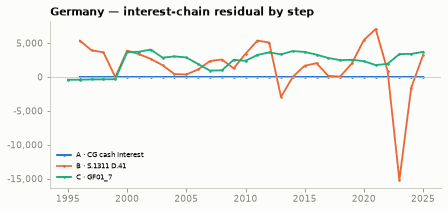

In [22]:
residual_over_time(INTEREST, "DEU", ["A_cg_cash", "B_s1311_d41", "C_s13_gf01_7"],
                    "Germany — interest-chain residual by step")


## 5. The financing chain

`debt_financing_reconciliation.csv` mirrors §4's shape for financing:
register net issuance → step A (central-government net cash requirement /
besoin de financement / Nettokreditaufnahme) → step B (S.1311 net borrowing)
→ step C (the package's `NLB`, as net borrowing). The waterfalls read the same
way as the interest chain.

**Sign convention.** The whole chain runs in **net-borrowing sign**: positive
when the government borrows more. The register sum and step A's official
total are published that way; the ESA quantities at steps B and C are net
lending(+)/borrowing(−), so the chain carries them as `−B.9` and `−NLB` and
says so in the `basis` column (`net borrowing = -B.9`). A residual at step B
is therefore a genuine reconciliation gap — the cash-to-accrual and
financial-transaction wedge (the stock-flow adjustment) — not a sign
artefact; where an official breakdown of that wedge exists (ONS REC2 for the
UK, Eurostat's EDP stock-flow items for France and Germany) it appears as
bridge items and the residual shrinks accordingly.


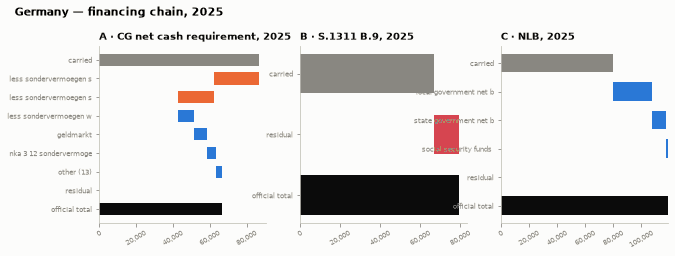

In [23]:
deu_fyear = waterfall_page(FINANCING, "DEU", ["A_cg_cash_requirement", "B_s1311_b9", "C_s13_nlb"], "financing")


**Reading the Germany panels.** Step A takes the register (the BMF instrument
tree, Bund-wide) to the core budget's Nettokreditaufnahme: money-market and
Schuldschein credits are added, the special funds' own borrowing (Sondervermögen
rows of the Datenportal) is subtracted, and the Kreditaufnahmebericht's own
derivation items (sonstige Einnahmen zur Schuldentilgung, Eigenbestand change,
the non-cash Selbstbewirtschaftung and special-fund lines, Rücklage) close the
step to zero for every edition whose annex parses. Step B's residual is the
stock-flow adjustment between the cash NKA and S.1311 net borrowing (accrual
timing, financial transactions such as loans and equity, the special funds
that are inside S.1311 but outside the NKA). Step C closes exactly once
state, local and social-security net borrowing are added: Eurostat's S.13
`B.9` is the sum of its four subsectors.


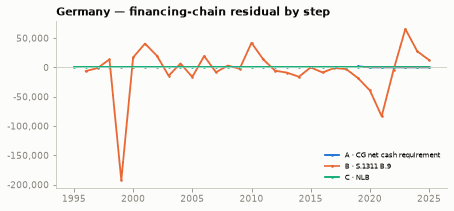

In [24]:
residual_over_time(FINANCING, "DEU", ["A_cg_cash_requirement", "B_s1311_b9", "C_s13_nlb"],
                    "Germany — financing-chain residual by step")


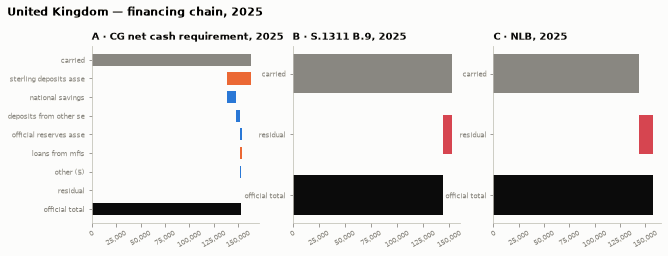

In [25]:
gbr_fyear = waterfall_page(FINANCING, "GBR", ["A_cg_cash_requirement", "B_s1311_b9", "C_s13_nlb"], "financing")


**Reading the UK panels.** Step A bridges the register (gilts + T-bills from
ONS Appendix S) to the CGNCR with the remaining Appendix S lines — National
Savings, tax instruments, deposits, loans, reserves and sterling deposits —
and closes to zero: the ONS table is an identity. Step B's residual is the
CGNCR-to-CG-net-borrowing reconciliation (ONS REC2: accruals adjustments and
financial transactions such as student loans, equity injections and
lending), itemised where the reader exposes the columns. Step C's residual is
local government's net borrowing plus consolidation, published as one number
unless the PSF local-government tables are itemised.


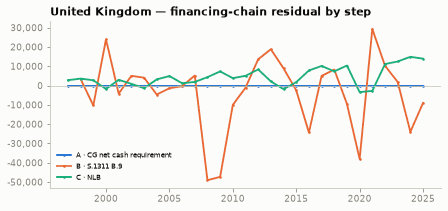

In [26]:
residual_over_time(FINANCING, "GBR", ["A_cg_cash_requirement", "B_s1311_b9", "C_s13_nlb"],
                    "United Kingdom — financing-chain residual by step")


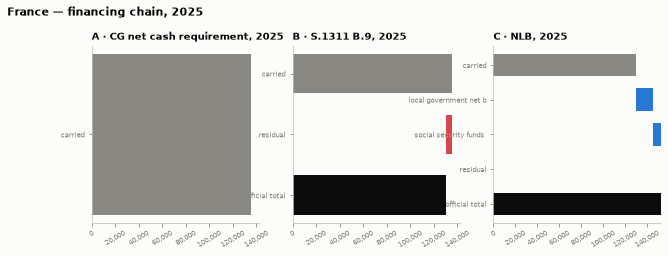

In [27]:
fra_fyear = waterfall_page(FINANCING, "FRA", ["A_cg_cash_requirement", "B_s1311_b9", "C_s13_nlb"], "financing")


**Reading the France panels.** Unlike the interest chain, the financing
register itself is *not* blocked here — the INSEE-redistributed AFT aggregates
(BTF and OAT/BTAN, from 2010) and Eurostat's S.1311 short- and long-term
securities (from 2001) carry net issuance as the year-on-year change in the
stock — so panel A shows a "carried" bar. What is blocked is the **official
total it should reconcile to**: `FRA_AFT_FINANCEMENT`, the AFT's own tableau
de financement, has no data in this run (OQ-8), so panel A has no closing bar
and no residual. Step B therefore reconciles the register directly against
S.1311 net borrowing; its residual is the stock-flow adjustment (buy-backs and
indexation are inside the Δstock, financial transactions and accruals are
not) plus the ODAC perimeter (CADES and the other central bodies are S.1311
but not the État). Step C closes exactly once local-government and
social-security net borrowing are added.


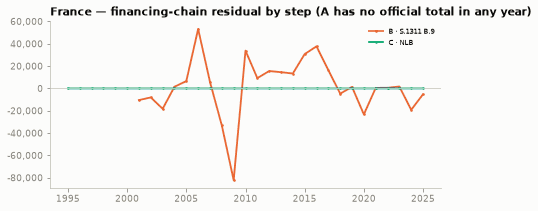

In [28]:
residual_over_time(FINANCING, "FRA", ["B_s1311_b9", "C_s13_nlb"],
                    "France — financing-chain residual by step (A has no official total in any year)")


## 6. Coverage

Two summaries of how much of each chain is actually populated, rather than
reading it off the charts above one country at a time.

**First and last year with a value**, per (country, chain, step) — for the
official total the chain reconciles to, and separately for the residual that
step actually published (a step can carry an official total for a year but
no residual, when the previous step's carried value is itself unknown — see
France's step B above).


In [29]:
def coverage(df, chain):
    d = df.copy()
    d["chain"] = chain
    off = d[d.item == "official_total"].dropna(subset=["value_lcu_mn"])
    res = d[d.item == "residual"].dropna(subset=["value_lcu_mn"])
    g_off = off.groupby(["iso3", "chain", "step"]).year.agg(official_total_first="min", official_total_last="max")
    g_res = res.groupby(["iso3", "chain", "step"]).year.agg(residual_first="min", residual_last="max")
    return g_off.join(g_res, how="outer")


cov = pd.concat([coverage(INTEREST, "interest"), coverage(FINANCING, "financing")]).sort_index()
cov


official_total_first  \
iso3 chain     step                                          
DEU  financing A_cg_cash_requirement                  2019   
               B_s1311_b9                             1995   
               C_s13_nlb                              1995   
               register                               1996   
     interest  A_cg_cash                              1996   
               B_s1311_d41                            1995   
               C_s13_gf01_7                           1991   
               register                               1996   
FRA  financing B_s1311_b9                             1995   
               C_s13_nlb                              1995   
               register                               2001   
     interest  B_s1311_d41                            1995   
               C_s13_gf01_7                           1978   
GBR  financing A_cg_cash_requirement                  1997   
               B_s1311_b9                             1998   
               C_s13_nlb                              1990   
               register                               1997   
     interest  A_cg_cash                              2009   
               B_s1311_d41                            1987   
               C_s13_gf01_7                           1987   
               register                               2009   

                                      official_total_last  residual_first  \
iso3 chain     step                                                         
DEU  financing A_cg_cash_requirement                 2025          2019.0   
               B_s1311_b9                            2025          1996.0   
               C_s13_nlb                             2025          1995.0   
               register                              2025             NaN   
     interest  A_cg_cash                             2025          1996.0   
               B_s1311_d41                           2025          1996.0   
               C_s13_gf01_7                          2025          1995.0   
               register                              2025             NaN   
FRA  financing B_s1311_b9                            2025          2001.0   
               C_s13_nlb                             2025          1995.0   
               register                              2025             NaN   
     interest  B_s1311_d41                           2025             NaN   
               C_s13_gf01_7                          2025          1995.0   
GBR  financing A_cg_cash_requirement                 2025          1997.0   
               B_s1311_b9                            2025          1998.0   
               C_s13_nlb                             2025          1997.0   
               register                              2025             NaN   
     interest  A_cg_cash                             2024          2009.0   
               B_s1311_d41                           2025          2009.0   
               C_s13_gf01_7                          2025          1987.0   
               register                              2024             NaN   

                                      residual_last  
iso3 chain     step                                  
DEU  financing A_cg_cash_requirement         2025.0  
               B_s1311_b9                    2025.0  
               C_s13_nlb                     2025.0  
               register                         NaN  
     interest  A_cg_cash                     2025.0  
               B_s1311_d41                   2025.0  
               C_s13_gf01_7                  2025.0  
               register                         NaN  
FRA  financing B_s1311_b9                    2025.0  
               C_s13_nlb                     2025.0  
               register                         NaN  
     interest  B_s1311_d41                      NaN  
               C_s13_gf01_7                  2025.0  
GBR  financing A_cg_cash_requ

**Which sources are blocked** — an `item_source_id` that appears only ever
paired with a null value, across all three chain/total files, is a source
this run could not reach at all (as opposed to one that is simply outside a
year's coverage).


In [30]:
def all_null_sources(df):
    g = df.groupby(["iso3", "item_source_id"]).value_lcu_mn.apply(lambda s: s.isna().all())
    return g[g].reset_index()[["iso3", "item_source_id"]]


blocked = pd.concat([
    all_null_sources(INTEREST).assign(chain="interest"),
    all_null_sources(FINANCING).assign(chain="financing"),
    all_null_sources(OFFICIAL).assign(chain="official_totals"),
]).drop_duplicates(subset=["iso3", "item_source_id"]).sort_values(["iso3", "item_source_id"])
blocked.reset_index(drop=True)


,iso3,item_source_id,chain
0,FRA,FRA_AFT_FINANCEMENT,financing
1,FRA,FRA_PLF_P117,interest


## 7. What changes when the per-security register arrives

Nothing in this notebook's *shape* changes — the two chains, their steps and
their published-not-allocated residuals are the target architecture already,
not a placeholder for it. What changes is where the register-step numbers in
§4 and §5 come from:

- **Register items become computed sums**, not published aggregates. Today's
  `sum_fixed_bullet`, `sum_mixed`, `sum_bill`, … are the debt offices' own
  class totals (`debt_class_aggregates`, DD8). Once the per-security register
  is built, the same items become `Σ debt_interest_by_security` (for §4) and
  `Σ debt_flows` net of redemptions and buybacks (for §5) — grouped by
  `instrument_class`, computed at security level, day-counted per
  DEBT_KICKOFF.md §7.
- **This notebook's aggregate rows do not disappear** — they become the
  **V31 / V39 cross-checks**: Σ positions by class at 31 December against
  the official stock by instrument (V31), and interest by class against the
  ministry's own by-instrument interest (BMF; programme 117; the DMR) where
  published (V39). Both are reported, not enforced — a mismatch between the
  register and the aggregate layer is exactly the kind of thing this
  notebook exists to surface, not to reconcile away.
- **The maturity profile and issuance-by-bucket tables** (§5.9–5.10 of
  `DEBT_KICKOFF.md`) have no aggregate-layer analogue at all — residual
  maturity requires a security's actual maturity date — so those sections
  are net-new once the register exists, not replacements for anything shown
  here.
- **The reconciliation chains, waterfalls and residual-over-time charts stay
  exactly as they are now** — steps A/B/C, the bridge items, the published
  residual — because DD4/DD5 fix that shape independently of where the
  register-step number comes from.
